# Loan Default Risk Analysis & Early Warning System

## FinTrust Lending Co.

### Project Objective

This project analyzes loan-level data from FinTrust Lending Co. to identify the major drivers of loan default, quantify financial exposure, and develop an early warning framework for identifying high-risk borrowers.

### Business Problem

FinTrust is experiencing a high loan default rate, creating significant financial losses. The objective of this analysis is to determine:

- Which borrower and loan characteristics are associated with higher default risk?
- Which loan grades and purposes contribute most to portfolio losses?
- How strongly do prior defaults and debt burden influence future default?
- Which borrower segments require stricter lending policies?
- Can a composite risk flag effectively identify high-risk borrowers before approval?

### Analytical Approach

The analysis follows these stages:

1. Data loading and initial inspection
2. Data quality assessment
3. Data cleaning and validation
4. Exploratory Data Analysis
5. Statistical testing and validation
6. Financial exposure analysis
7. Early warning risk assessment
8. Business recommendations

### Dataset

The analysis uses a cleaned loan-level dataset containing **32,416 loan records and 13 variables** after data-quality processing.

### Key Outcome

The final analysis is designed to translate statistical findings into actionable credit-risk recommendations for FinTrust Lending Co.

## Analytical Questions

This analysis is designed to answer the following business questions:

1. What is FinTrust Lending Co.'s overall loan default rate?
2. Which loan grades have the highest default risk?
3. Which loan purposes are associated with higher default rates?
4. Does prior default history significantly increase the probability of future default?
5. How does debt burden, measured through loan-to-income ratio, affect default risk?
6. Does borrower income level influence default risk?
7. How does borrower age relate to default risk?
8. Which borrower segments contribute the greatest financial exposure?
9. Which loan grades generate the largest absolute default losses?
10. Can a composite early-warning risk flag effectively separate high-risk borrowers from normal borrowers?
11. Are the observed differences in default rates statistically significant?
12. What credit-policy changes should FinTrust implement based on the evidence?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Dataset
df = pd.read_csv("/content/credit_risk_dataset.csv")
df.shape
df.columns.tolist()

# Dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()

# Data types
print(df.dtypes)
print()

# Preview
df.head()

Rows: 32581
Columns: 12

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
#Missing values
print("\n Missing values: \n")
missing=df.isnull().sum()
missing_percent=(missing/df.shape[0]*100).round(2)
print(missing_percent)

missing_data=pd.DataFrame({
    "Missing values":missing,
    "Missing %":missing_percent
})
missing_data=missing_data[missing_data["Missing values"]>0]
if missing_data.empty:
  print("No missing values")
else:
  print(missing_data)


 Missing values: 

person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64
                   Missing values  Missing %
person_emp_length             895       2.75
loan_int_rate                3116       9.56


In [3]:
#Numerical data
duplicates=df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
print(df.describe().round(2))


Number of duplicates: 165
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           31686.00   32581.00       29465.00   
mean        27.73       66074.85               4.79    9589.37          11.01   
std          6.35       61983.12               4.14    6322.09           3.24   
min         20.00        4000.00               0.00     500.00           5.42   
25%         23.00       38500.00               2.00    5000.00           7.90   
50%         26.00       55000.00               4.00    8000.00          10.99   
75%         30.00       79200.00               7.00   12200.00          13.47   
max        144.00     6000000.00             123.00   35000.00          23.22   

       loan_status  loan_percent_income  cb_person_cred_hist_length  
count     32581.00             32581.00                    32581.00  
mean          0.22                 0.17                        5.80  
std           0.41                

In [4]:
#Categorical data
categories=["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
for col in categories:
  print(df[col].value_counts())

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [5]:
invalid_employee=df[df['person_emp_length']>(df['person_age']-16)]
print(f"Number of invalid records: {len(invalid_employee)}")
print(invalid_employee[["person_age", "person_emp_length"]].head(10))

Number of invalid records: 740
     person_age  person_emp_length
0            22              123.0
9            21                6.0
18           23                8.0
65           22                7.0
68           24                9.0
72           21                6.0
125          23                8.0
141          26               11.0
171          21                6.0
210          21              123.0


In [6]:
#Data Cleaning

In [7]:
#remove duplicates
original_rows=len(df)
emp_nulls_before = df['person_emp_length'].isnull().sum()
print(f"emp_length nulls before duplicate removal: {emp_nulls_before}")
print()
df=df.drop_duplicates()
df=df.reset_index(drop=True)
emp_nulls_after = df['person_emp_length'].isnull().sum()
print(f"emp_length nulls after duplicate removal: {emp_nulls_after}")
print(f"nulls lost in duplicate removal: {emp_nulls_before - emp_nulls_after}")
print(f"duplicates removed: {original_rows - len(df)}")


emp_length nulls before duplicate removal: 895

emp_length nulls after duplicate removal: 887
nulls lost in duplicate removal: 8
duplicates removed: 165


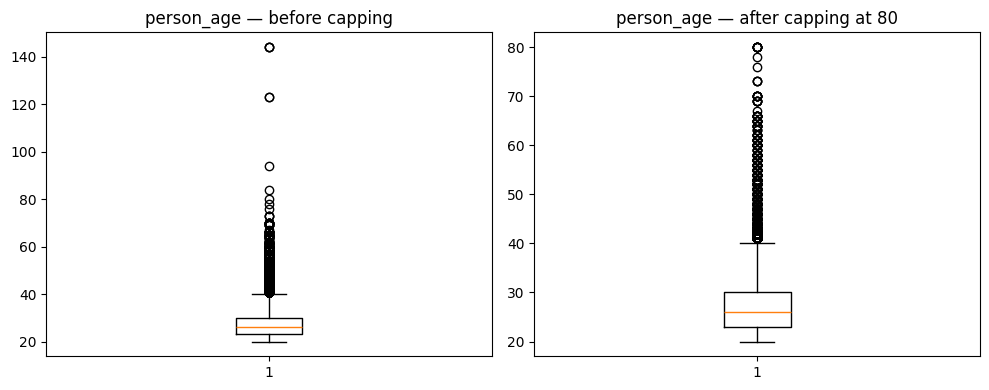

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['person_age'].dropna())
axes[0].set_title('person_age — before capping')
axes[1].boxplot(df['person_age'].clip(upper=80))
axes[1].set_title('person_age — after capping at 80')
plt.tight_layout()
plt.show()

In [9]:
#Fixing impossible age values
#Capping at 80 as reasonable maximum for a loan applicant
print(f"Ages above 80:{len(df[df['person_age']>80])}")
df['person_age']=df['person_age'].clip(upper=80)
print(f"Ages above 80:{len(df[df['person_age']>80])}")
assert df['person_age'].max() <= 80, "Age cap failed"

Ages above 80:7
Ages above 80:0


In [10]:
#Fixing impossible employment lengths
print(f"Impossible employment lengths: {len(df[df['person_emp_length']>df['person_age']-16])}")
max_possible_emp_length = df['person_age'] - 16
df['person_emp_length'] = np.minimum(df['person_emp_length'], max_possible_emp_length)

print(f"Impossible employment lengths after: {len(df[df['person_emp_length']>(df['person_age']-16)])}")
print(f"Maximum employment length after fix: {df['person_emp_length'].max()}")
valid = df['person_emp_length'].notnull()
assert (df.loc[valid, 'person_emp_length'] <= df.loc[valid, 'person_age'] - 16).all(), "Employment length cap failed"

Impossible employment lengths: 737
Impossible employment lengths after: 0
Maximum employment length after fix: 41.0


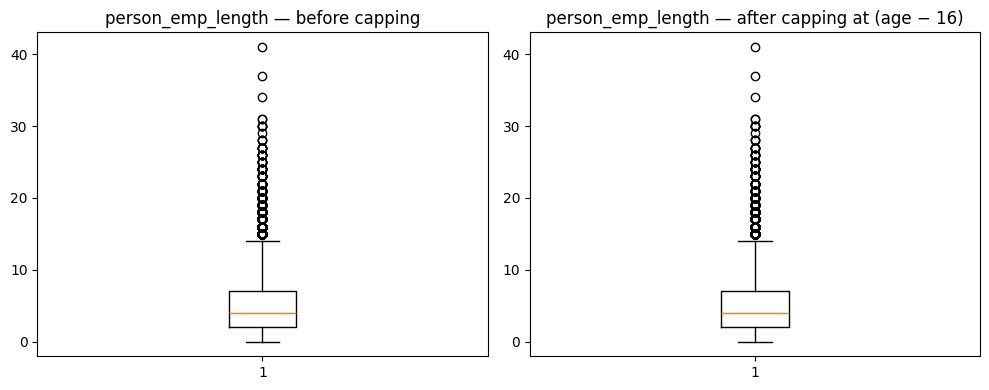

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['person_emp_length'].dropna())
axes[0].set_title('person_emp_length — before capping')
axes[1].boxplot(np.minimum(df['person_emp_length'], df['person_age'] - 16).dropna())
axes[1].set_title('person_emp_length — after capping at (age − 16)')
plt.tight_layout()
plt.show()

In [12]:
# Handling Employment Null values
# Track missing information before imputing 0
df['emp_length_missing'] = df['person_emp_length'].isnull().astype(int)
df['person_emp_length'] = df['person_emp_length'].fillna(0)

print(f"Number of null values in employment length: {df['person_emp_length'].isnull().sum()}")
print(f"Missing employment records flagged as 1: {df['emp_length_missing'].sum()}")

assert df['person_emp_length'].isnull().sum() == 0, "Unfilled emp_length nulls remain"
assert df['emp_length_missing'].isin([0, 1]).all(), "Invalid emp_length_missing values"

Number of null values in employment length: 0
Missing employment records flagged as 1: 887


In [13]:
#Handling Interest Rate nulls
print(f"Missing interest rate values: {df['loan_int_rate'].isnull().sum()}")
df['loan_int_rate']=df.groupby('loan_grade')['loan_int_rate'].transform(lambda x:x.fillna(x.median()))
print(f"Missing interest rate values after: {df['loan_int_rate'].isnull().sum()}")
print("\n Median interest rate by grade:")
print(df.groupby('loan_grade')['loan_int_rate'].median().round(2))
assert df['loan_int_rate'].isnull().sum() == 0, "Unfilled interest rate nulls remain"


Missing interest rate values: 3095
Missing interest rate values after: 0

 Median interest rate by grade:
loan_grade
A     7.49
B    10.99
C    13.48
D    15.31
E    16.82
F    18.54
G    20.16
Name: loan_int_rate, dtype: float64


In [14]:
Q1=df['person_income'].quantile(0.25)
Q3=df['person_income'].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
income_before_capping = df['person_income'].copy()   # snapshot for the before/after plot
print(f"Income above fence:${upper_bound}")
print(f"Number of outliers:{len(df[df['person_income']>upper_bound])}")
df['person_income']=df['person_income'].clip(upper=upper_bound)

Income above fence:$140232.0
Number of outliers:1478


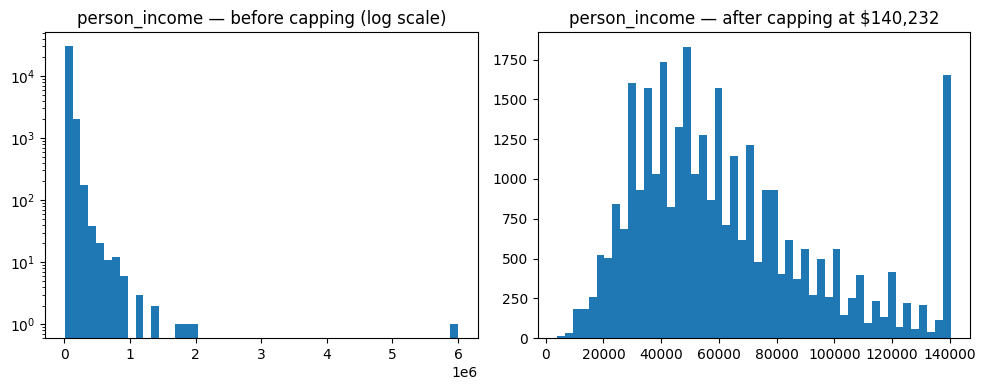

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(income_before_capping, bins=50)
axes[0].set_yscale('log')
axes[0].set_title('person_income — before capping (log scale)')
axes[1].hist(df['person_income'].clip(upper=upper_bound), bins=50)
axes[1].set_title(f'person_income — after capping at ${upper_bound:,.0f}')
plt.tight_layout()
plt.show()

In [16]:
#Standardising categorical columns
for col in categories:
  df[col]=df[col].str.strip().str.upper()
for col in categories:
  print(f"\n{col}:")
  print(df[col].value_counts())


person_home_ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [17]:
# Final validation check

print(f"Row count: {df.shape[0]}")
print(f"Column count: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")
print()

print("Nulls remaining across all columns:")
print(df.isnull().sum())
print()

print("Data types:")
print(df.dtypes)
print()

print("Summary statistics after cleaning:")
print(df[['person_age', 'person_income', 'person_emp_length', 'loan_int_rate']].describe().round(2))
print()

print("Unique values in categorical columns:")
for col in categories:
    print(f"  {col}: {sorted(df[col].unique())}")
print()

# Final assertions
assert df.isnull().sum().sum() == 0, "Nulls remain in dataset"
assert df.shape == (32416, 13), f"Unexpected dataset shape: {df.shape}"
assert df['emp_length_missing'].isin([0, 1]).all(), "Invalid emp_length_missing flag"

default_rate = df['loan_status'].mean() * 100
print(f"Overall default rate: {default_rate:.2f}%")
print(f"Total defaulted loans: {df['loan_status'].sum():,}")
print(f"Total non-defaulted loans: {(df['loan_status'] == 0).sum():,}")
print("\nAll validation checks passed successfully.")

Row count: 32416
Column count: 13
Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'emp_length_missing']

Nulls remaining across all columns:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
emp_length_missing            0
dtype: int64

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     o

In [18]:
#Saving cleaned dataset
df.to_csv('credit_risk_cleaned.csv', index=False)
print("Cleaned file saved as credit_risk_cleaned.csv")

Cleaned file saved as credit_risk_cleaned.csv


# Phase 7 — Exploratory Data Analysis

Answering 10 business questions visually.  
Each chart is tied directly to a finding from the SQL analysis in Phase 6.  
Dataset: 32,416 cleaned loan records — FinTrust Lending Co.

In [19]:
# EDA setup
# Uses the cleaned and prepared dataset loaded earlier in the notebook

# global chart settings
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

# colour palette
COLORS = {
    'primary': '#2E86AB',
    'warning': '#F6AE2D',
    'danger':  '#E84855',
    'safe':    '#43AA8B',
    'neutral': '#8D99AE'
}

# grade colours — green to red
GRADE_COLORS = {
    'A': '#43AA8B',
    'B': '#90BE6D',
    'C': '#F9C74F',
    'D': '#F8961E',
    'E': '#F3722C',
    'F': '#E84855',
    'G': '#9B2335'
}

print(f'loaded: {len(df):,} rows')
print(f'default rate: {df.loan_status.mean()*100:.2f}%')
print(f'total defaults: {df.loan_status.sum():,}')
print('setup complete')

loaded: 32,416 rows
default rate: 21.87%
total defaults: 7,089
setup complete


## Chart 1 — Overall Default Rate

**Business question:** What is FinTrust's current default rate at a glance?

**Why this chart:** Every analysis needs an opening number. Before showing any breakdown,
the CRO needs to see the scale of the problem in one visual.

**What we expect:** 21.87% of loans defaulted — roughly 1 in 5.

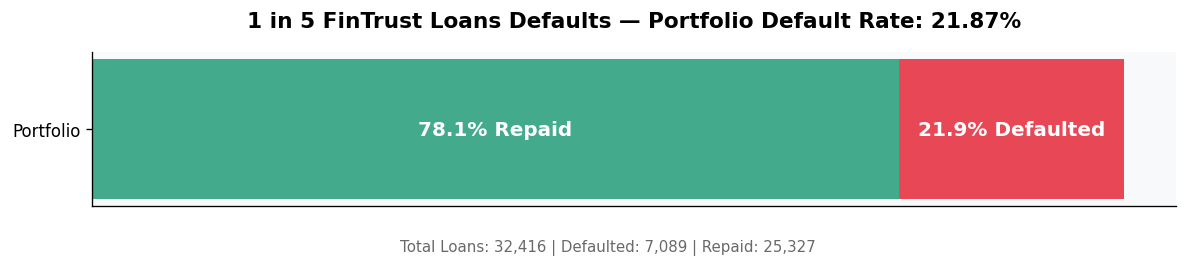

Insight: FinTrust has a default rate of 21.87%, meaning about 1 in 5 loans end in default.


In [20]:
# Chart 1 - Overall Default Rate Snapshot
# Business Question: What is FinTrust's overall loan default rate?

# Calculate portfolio metrics
default_rate = df['loan_status'].mean() * 100
repaid_rate = 100 - default_rate

total_loans = len(df)
defaulted_loans = df['loan_status'].sum()
repaid_loans = total_loans - defaulted_loans

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.5))

# Plot stacked horizontal bar
ax.barh(
    ['Portfolio'],
    [repaid_rate],
    color=COLORS['safe'],
    height=0.5,
    label='Repaid'
)

ax.barh(
    ['Portfolio'],
    [default_rate],
    left=[repaid_rate],
    color=COLORS['danger'],
    height=0.5,
    label='Defaulted'
)

# Percentage labels inside each section
ax.text(
    repaid_rate / 2,
    0,
    f'{repaid_rate:.1f}% Repaid',
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    repaid_rate + default_rate / 2,
    0,
    f'{default_rate:.1f}% Defaulted',
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

# Chart title
ax.set_title(
    f'1 in 5 FinTrust Loans Defaults — Portfolio Default Rate: {default_rate:.2f}%',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Display loan counts below the chart
ax.text(
    50,
    -0.42,
    f'Total Loans: {total_loans:,} | Defaulted: {defaulted_loans:,} | Repaid: {repaid_loans:,}',
    ha='center',
    va='center',
    fontsize=9,
    color='dimgray'
)

# Clean up chart appearance
ax.set_xticks([])
ax.set_ylabel('')
ax.grid(False)

plt.tight_layout()
plt.savefig('chart1_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: FinTrust has a default rate of {default_rate:.2f}%, meaning about 1 in 5 loans end in default.')

## Chart 2 — Default Rate by Loan Grade

**Business question:** Which loan grades are destroying FinTrust's portfolio?

**Why this chart:** SQL showed Grade G at 98.44% — almost every approval is a loss.
This needs to be seen visually with the full grade spectrum.

**What we expect:** A clear escalation from Grade A (low risk) to Grade G (extremely elevated observed default risk).

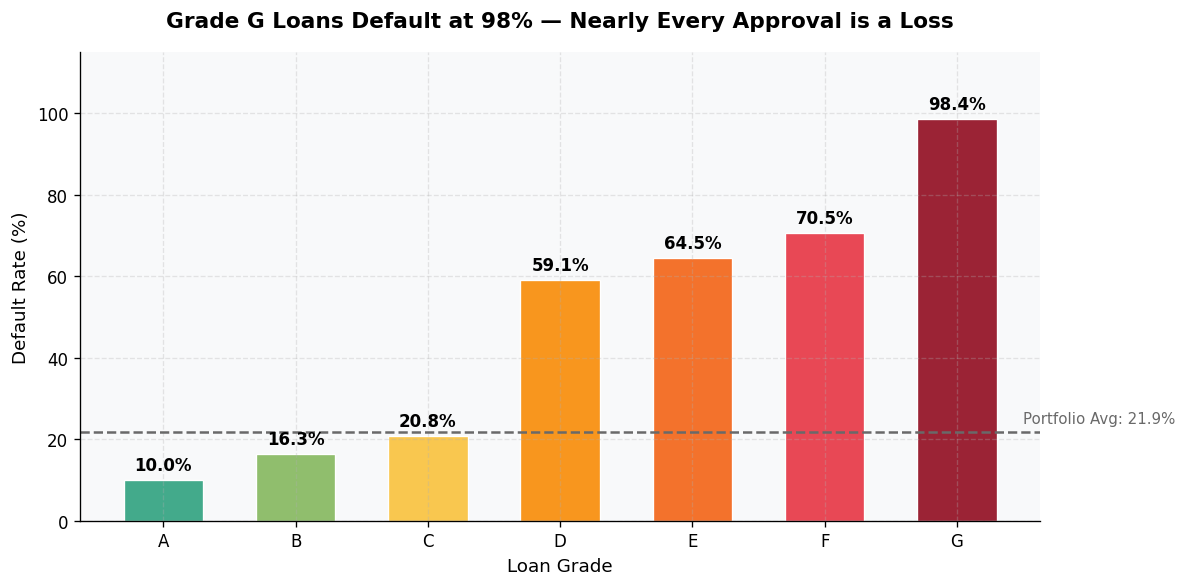

insight: grades E, F, G all exceed 60% default rate
Insight: Grades A and B show comparatively lower observed default rates and represent lower-risk segments within this portfolio.
Insight: Grade G shows extremely elevated observed default risk. FinTrust should apply enhanced underwriting and review lending policy for this segment rather than automatically suspending all approvals.


In [21]:
# chart 2 - default rate by loan grade
# business question: which grades are destroying fintrust's portfolio?

grade_data = (
    df.groupby('loan_grade')['loan_status']
      .mean()
      .reset_index()
)
grade_data['default_rate'] = grade_data['loan_status'] * 100
grade_data = grade_data.sort_values('loan_grade')

portfolio_avg = df['loan_status'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    grade_data['loan_grade'],
    grade_data['default_rate'],
    color=[GRADE_COLORS[g] for g in grade_data['loan_grade']],
    width=0.6, edgecolor='white', linewidth=0.8
)

# data labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# portfolio average line
ax.axhline(portfolio_avg, color='dimgray',
           linestyle='--', linewidth=1.5)
ax.text(
    len(grade_data) - 0.5,
    portfolio_avg + 2,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9, color='dimgray'
)

ax.set_title(
    'Grade G Loans Default at 98% — Nearly Every Approval is a Loss',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Loan Grade', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('chart2_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print('insight: grades E, F, G all exceed 60% default rate')
print('Insight: Grades A and B show comparatively lower observed default rates '
    'and represent lower-risk segments within this portfolio.')
print('Insight: Grade G shows extremely elevated observed default risk. '
    'FinTrust should apply enhanced underwriting and review lending policy '
    'for this segment rather than automatically suspending all approvals.')

## Chart 3 — Default Rate by Loan Intent

**Business question:** Which loan purposes carry the highest default risk?

**Why this chart:** SQL found Debt Consolidation, Medical, and Home Improvement
all exceed the portfolio average. The credit team needs to see this ranked clearly.

**What we expect:** Debt Consolidation highest, Education or Personal lowest.

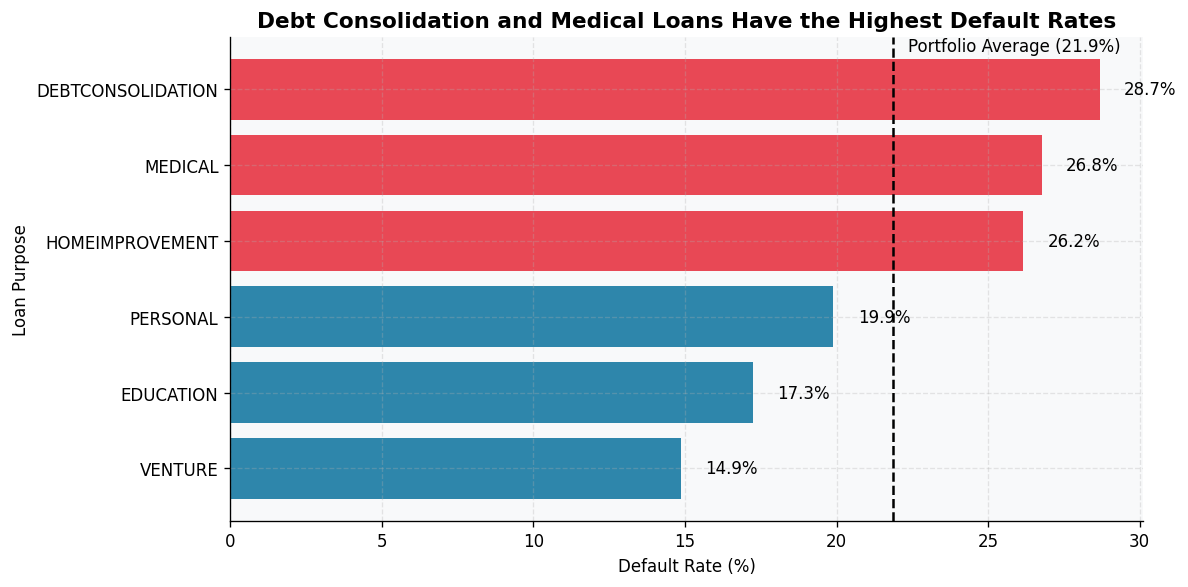

Insight: Debt consolidation and medical loans default more often than the portfolio average, while education and personal loans perform relatively better.
insight: debt consolidation, medical, and home improvement exceed portfolio average
insight: apply stricter grade and LTI requirements for these three intents


In [22]:
# Chart 3 - Default Rate by Loan Intent
# Business Question: Which loan purposes are the riskiest?
# Calculate default rate for each loan purpose
intent_data = (
    df.groupby('loan_intent')['loan_status']
      .mean()
      .reset_index()
)
intent_data['default_rate'] = intent_data['loan_status'] * 100
intent_data = intent_data.sort_values('default_rate', ascending=True)
# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100
# Set bar colours based on portfolio average
bar_colors = [
    COLORS['danger'] if rate > portfolio_avg else COLORS['primary']
    for rate in intent_data['default_rate']
]
# Create figure
fig, ax = plt.subplots(figsize=(10, 5))
# Horizontal bars
bars = ax.barh(
    intent_data['loan_intent'],
    intent_data['default_rate'],
    color=bar_colors
)
# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )
# Portfolio average reference line
ax.axvline(
    portfolio_avg,
    color='black',
    linestyle='--',
    linewidth=1.5
)
# Label the reference line
ax.text(
    portfolio_avg + 0.5,
    len(intent_data) - 0.5,
    f'Portfolio Average ({portfolio_avg:.1f}%)',
    fontsize=10,
    color='black'
)
# Chart title
ax.set_title(
    'Debt Consolidation and Medical Loans Have the Highest Default Rates',
    fontsize=13,
    fontweight='bold'
)
# Axis labels
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Loan Purpose')
plt.tight_layout()
plt.savefig('chart3_default_rate_by_intent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Debt consolidation and medical loans default more often than the portfolio average, while education and personal loans perform relatively better.")
print('insight: debt consolidation, medical, and home improvement exceed portfolio average')
print('insight: apply stricter grade and LTI requirements for these three intents')

## Chart 4 — Prior Default Impact

**Business question:** How much more likely is a borrower with a prior default to default again?

**Why this chart:** The analysis shows that borrowers with a prior default on file have approximately 2.05x the observed default rate of borrowers without a prior default.
A side-by-side bar comparison makes this contrast impossible to ignore.

**What we expect:** Y borrowers defaulting at ~38%, N borrowers at ~18%.

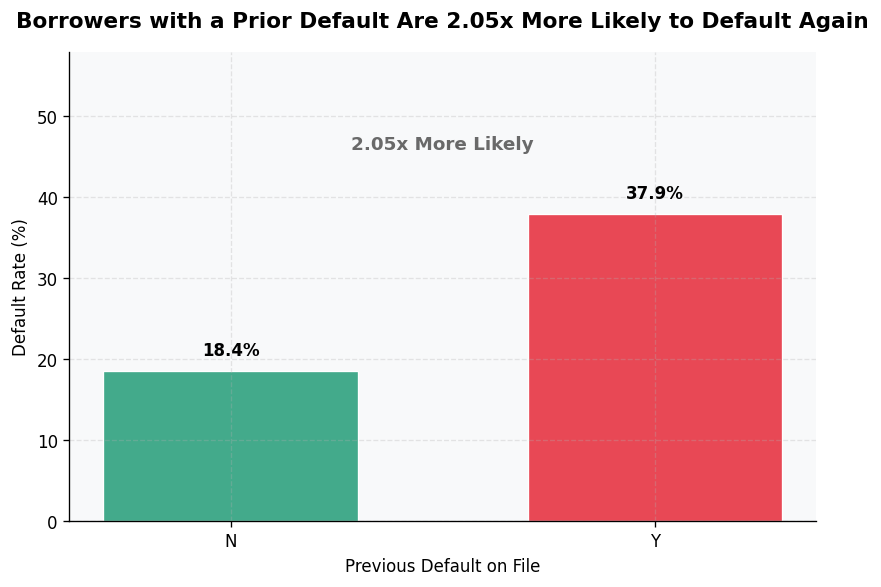

Insight: Borrowers with a previous default are 2.05x more likely to default again.
Insight: Prior default history is one of the strongest observed risk indicators in this portfolio.


In [23]:
# Chart 4 - Impact of Previous Loan Default
# Business Question: How much more likely is a borrower to default again?

# Calculate default rate based on previous default history
prior_data = (
    df.groupby('cb_person_default_on_file')['loan_status']
      .mean()
      .reset_index()
)

prior_data['default_rate'] = prior_data['loan_status'] * 100

# Calculate repeat default multiplier
repeat_multiplier = (
    prior_data.loc[prior_data['cb_person_default_on_file'] == 'Y', 'default_rate'].iloc[0] /
    prior_data.loc[prior_data['cb_person_default_on_file'] == 'N', 'default_rate'].iloc[0]
)

# Set colours for each category
bar_colors = [
    COLORS['danger'] if status == 'Y' else COLORS['safe']
    for status in prior_data['cb_person_default_on_file']
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Create bars
bars = ax.bar(
    prior_data['cb_person_default_on_file'],
    prior_data['default_rate'],
    color=bar_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add annotation showing repeat default multiplier
ax.text(
    0.5,
    max(prior_data['default_rate']) + 8,
    f'{repeat_multiplier:.2f}x More Likely',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='dimgray'
)

# Chart title
ax.set_title(
    f'Borrowers with a Prior Default Are {repeat_multiplier:.2f}x More Likely to Default Again',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Previous Default on File')
ax.set_ylabel('Default Rate (%)')
ax.set_ylim(0, max(prior_data['default_rate']) + 20)

plt.tight_layout()
plt.savefig('chart4_prior_default_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: Borrowers with a previous default are {repeat_multiplier:.2f}x more likely to default again.')
print('Insight: Prior default history is one of the strongest observed risk indicators in this portfolio.')

## Chart 5 — LTI Threshold vs Default Rate

**Business question:** Does a 35% loan-to-income threshold effectively separate higher-risk borrowers from the rest of the portfolio?

**Why this chart:** A high loan-to-income ratio can indicate greater repayment pressure. This analysis tests whether borrowers above FinTrust's 35% LTI threshold exhibit materially higher observed default rates.

**What we evaluate:** Default rates for borrowers at or below 35% LTI versus borrowers above 35% LTI.

**Business relevance:** If the difference is substantial, the 35% threshold can be used as an early-warning trigger for enhanced credit review.

**Important:** This analysis evaluates whether 35% provides strong risk separation in this dataset; it does not establish that 35% is the mathematically optimal lending cutoff.

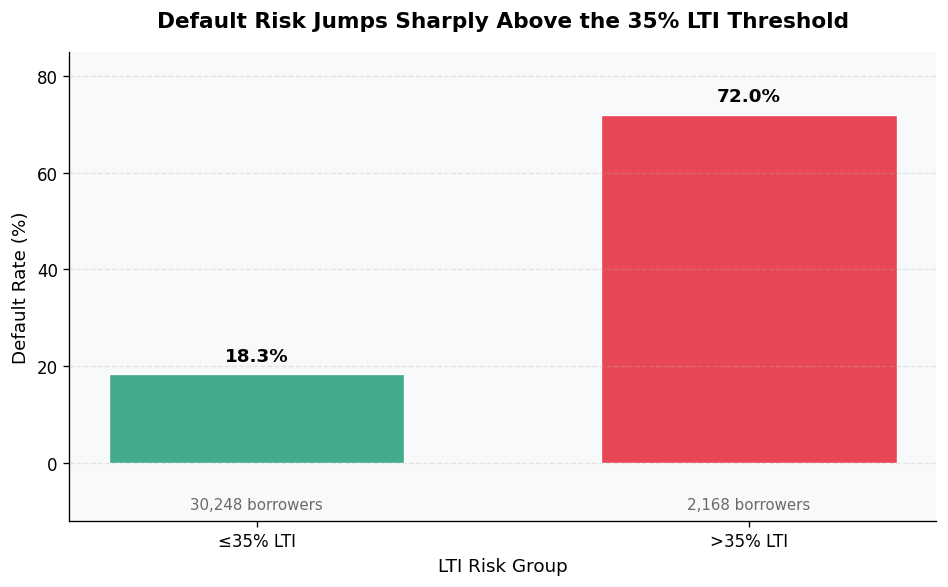

Insight: Default rate is 18.28% for borrowers at or below 35% LTI.
Insight: Default rate rises to 71.96% for borrowers above 35% LTI.
Insight: The difference is 53.68 percentage points.
Insight: The 35% LTI threshold provides strong risk separation and is suitable as an early-warning trigger for enhanced credit review.


In [24]:
# Chart 5 - LTI Threshold vs Default Rate
# Business Question:
# Does the 35% LTI threshold effectively separate higher-risk borrowers?

# Create the business-defined LTI risk groups
df['high_lti_35'] = np.where(
    df['loan_percent_income'] > 0.35,
    '>35% LTI',
    '≤35% LTI'
)

# Calculate default rate and borrower count
lti_data = (
    df.groupby('high_lti_35')['loan_status']
      .agg(['mean', 'count', 'sum'])
      .reset_index()
      .rename(columns={
          'mean': 'default_rate',
          'count': 'total_loans',
          'sum': 'defaults'
      })
)

lti_data['default_rate'] *= 100

# Keep the business order
lti_order = ['≤35% LTI', '>35% LTI']

lti_data['high_lti_35'] = pd.Categorical(
    lti_data['high_lti_35'],
    categories=lti_order,
    ordered=True
)

lti_data = lti_data.sort_values('high_lti_35')

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    lti_data['high_lti_35'],
    lti_data['default_rate'],
    color=[COLORS['safe'], COLORS['danger']],
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default-rate labels
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add borrower counts below the bars
for bar, count in zip(bars, lti_data['total_loans']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -7,
        f'{count:,} borrowers',
        ha='center',
        va='top',
        fontsize=9,
        color='dimgray'
    )

# Chart title
ax.set_title(
    'Default Risk Jumps Sharply Above the 35% LTI Threshold',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('LTI Risk Group', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)

# Formatting
ax.set_ylim(-12, 85)
ax.grid(axis='x', visible=False)

plt.tight_layout()

plt.savefig(
    'chart5_lti_default_rate.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Print business findings
low_lti_rate = lti_data.loc[
    lti_data['high_lti_35'] == '≤35% LTI',
    'default_rate'
].iloc[0]

high_lti_rate = lti_data.loc[
    lti_data['high_lti_35'] == '>35% LTI',
    'default_rate'
].iloc[0]

print(
    f'Insight: Default rate is {low_lti_rate:.2f}% '
    f'for borrowers at or below 35% LTI.'
)

print(
    f'Insight: Default rate rises to {high_lti_rate:.2f}% '
    f'for borrowers above 35% LTI.'
)

print(
    f'Insight: The difference is '
    f'{high_lti_rate - low_lti_rate:.2f} percentage points.'
)

print(
    'Insight: The 35% LTI threshold provides strong '
    'risk separation and is suitable as an early-warning trigger '
    'for enhanced credit review.'
)

## Statistical Analysis 3 — LTI Threshold and Default Risk

### Research Question

Do borrowers with loan-to-income ratios above 35% have a significantly higher default rate than borrowers at or below 35%?

### Hypotheses

**Null hypothesis (H₀):**  
There is no difference in default rates between borrowers above and below the 35% LTI threshold.

**Alternative hypothesis (H₁):**  
The default rates differ between the two LTI groups.

A two-proportion z-test is used because the outcome is binary (default vs. non-default) and we are comparing default proportions between two independent groups.

In [25]:
# Statistical test: LTI threshold vs default rate

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

# Extract default counts and total loans
defaults_high = int(
    lti_data.loc[
        lti_data['high_lti_35'] == '>35% LTI',
        'defaults'
    ].iloc[0]
)

total_high = int(
    lti_data.loc[
        lti_data['high_lti_35'] == '>35% LTI',
        'total_loans'
    ].iloc[0]
)

defaults_low = int(
    lti_data.loc[
        lti_data['high_lti_35'] == '≤35% LTI',
        'defaults'
    ].iloc[0]
)

total_low = int(
    lti_data.loc[
        lti_data['high_lti_35'] == '≤35% LTI',
        'total_loans'
    ].iloc[0]
)

# Two-proportion z-test
z_stat, p_value = proportions_ztest(
    count=[defaults_high, defaults_low],
    nobs=[total_high, total_low],
    alternative="two-sided"
)

# Risk ratio
risk_ratio = (
    defaults_high / total_high
) / (
    defaults_low / total_low
)

# Difference in default rates
rate_difference = (
    defaults_high / total_high
) - (
    defaults_low / total_low
)

# 95% confidence interval for the difference
ci_low, ci_high = confint_proportions_2indep(
    count1=defaults_high,
    nobs1=total_high,
    count2=defaults_low,
    nobs2=total_low,
    method="wald"
)

print("LTI THRESHOLD STATISTICAL ANALYSIS")
print("-" * 45)

print(f"≤35% LTI default rate: {defaults_low / total_low * 100:.2f}%")
print(f">35% LTI default rate: {defaults_high / total_high * 100:.2f}%")

print(
    f"Difference: {rate_difference * 100:.2f} "
    f"percentage points"
)

print(f"Risk ratio: {risk_ratio:.2f}x")
print(f"Z-statistic: {z_stat:.2f}")
print(f"P-value: {p_value:.10f}")

print(
    f"95% CI for difference: "
    f"{ci_low * 100:.2f} to {ci_high * 100:.2f} "
    f"percentage points"
)

LTI THRESHOLD STATISTICAL ANALYSIS
---------------------------------------------
≤35% LTI default rate: 18.28%
>35% LTI default rate: 71.96%
Difference: 53.68 percentage points
Risk ratio: 3.94x
Z-statistic: 58.41
P-value: 0.0000000000
95% CI for difference: 51.74 to 55.62 percentage points


### Interpretation

Borrowers with LTI above 35% have a **71.96% default rate**, compared with **18.28%** among borrowers at or below 35%.

This represents a **53.68 percentage-point difference** and a **3.94× higher observed risk** for borrowers above the threshold.

The two-proportion z-test produces a **z-statistic of 58.41** with **p < 0.001**, providing strong statistical evidence that the difference in default rates is not consistent with random sampling variation.

The 95% confidence interval indicates that the true difference in default rates is estimated to be between **51.74 and 55.62 percentage points**.

### Business implication

The 35% LTI threshold provides strong separation between lower- and higher-risk borrowers in this dataset. FinTrust could therefore use **LTI >35% as an early-warning trigger for enhanced credit review**, subject to validation on future or out-of-sample loan data.

**Important limitation:** Statistical significance does not establish that 35% is the optimal lending cutoff, nor does it establish that high LTI causes default. The result demonstrates a strong association between the threshold and observed default outcomes.

## Chart 6 — Income Band vs Default Rate

**Business question:** How does observed default risk vary across borrower income levels?

**Why this chart:** Borrower income is an important indicator of repayment capacity. This analysis examines whether default rates differ systematically across income bands.

**What we expect:** Lower-income borrowers are expected to show higher observed default rates than higher-income borrowers.

**Business relevance:** Identifying income segments with elevated default rates can help FinTrust apply appropriate affordability checks and risk-based underwriting policies.

**Important:** This analysis identifies an association between income and observed default rates. It does not establish that income alone causes or predicts default.

          income_band  loan_status  default_rate
0         Low\n(<30K)         0.47         47.20
1    Medium\n(30-60K)         0.26         25.86
2     High\n(60-100K)         0.13         13.21
3  Very High\n(100K+)         0.09          8.94


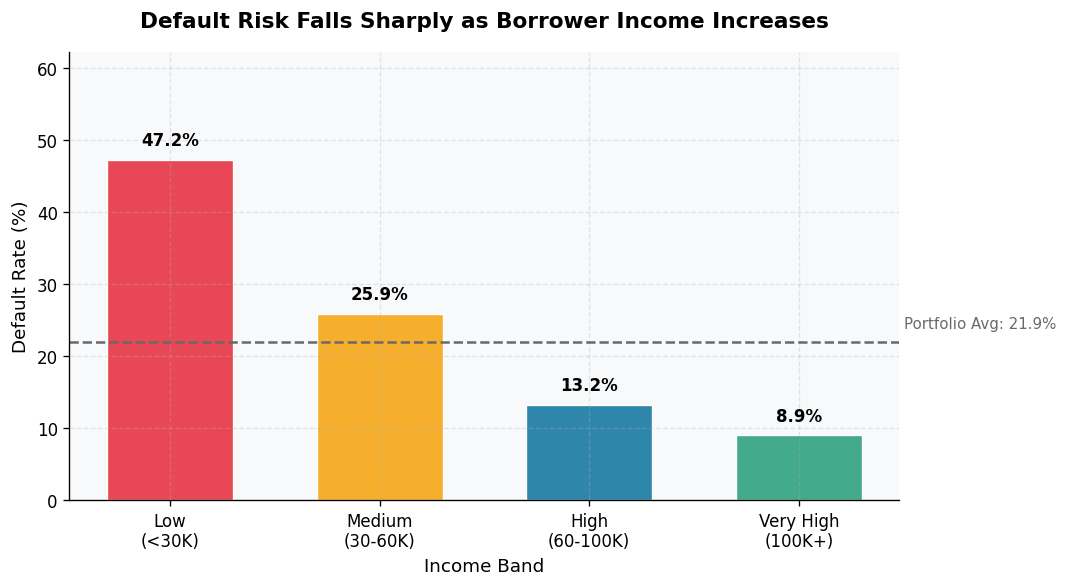

Insight: Lower-income borrowers show higher observed default rates than higher-income borrowers.
Insight: Default rates generally decline across the income bands, indicating an inverse association between income and observed default risk.
Insight: The Very High (100K+) income segment has the lowest observed default rate in this portfolio.


In [26]:
# Chart 6 - Income Band vs Default Rate
# Business Question: At what income level does default risk begin to fall?

# Create income bands
df['income_band'] = pd.cut(
    df['person_income'],
    bins=[0, 30000, 60000, 100000, df['person_income'].max() + 1],
    labels=['Low\n(<30K)', 'Medium\n(30-60K)', 'High\n(60-100K)', 'Very High\n(100K+)'],
    right=False  # matches Power BI: exact boundary values fall into the HIGHER band
)

# Calculate default rate for each income band
income_data = (
    df.groupby('income_band', observed=True)['loan_status']
      .mean()
      .reset_index()
)

income_data['default_rate'] = income_data['loan_status'] * 100
print(income_data.round(2))

# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100

# Risk colours from highest to lowest risk
income_colors = [
    COLORS['danger'],
    COLORS['warning'],
    COLORS['primary'],
    COLORS['safe']
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Create bars
bars = ax.bar(
    income_data['income_band'],
    income_data['default_rate'],
    color=income_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Portfolio average reference line
ax.axhline(
    portfolio_avg,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Label the reference line
ax.text(
    len(income_data) - 0.5,
    portfolio_avg + 2,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9,
    color='dimgray'
)

# Chart title
ax.set_title(
    'Default Risk Falls Sharply as Borrower Income Increases',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Income Band', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, max(income_data['default_rate']) + 15)

plt.tight_layout()
plt.savefig('chart6_income_band_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    'Insight: Lower-income borrowers show higher observed '
    'default rates than higher-income borrowers.'
)

print(
    'Insight: Default rates generally decline across the '
    'income bands, indicating an inverse association between '
    'income and observed default risk.'
)

print(
    'Insight: The Very High (100K+) income segment has the '
    'lowest observed default rate in this portfolio.'
)

## Chart 7 — Defaulted Principal Exposure by Grade

**Business question:** Which loan grades expose FinTrust to the largest amount of principal from defaulted loans?

**Why this chart:** Default rates show relative risk, but they do not show the financial scale of that risk. This analysis converts default activity into the total principal amount associated with defaulted loans.

**What we expect:** Mid-to-high risk grades may generate the largest absolute exposure because they combine elevated default rates with larger numbers of loans.

**Business relevance:** Identifying grades with high defaulted principal exposure helps FinTrust prioritize portfolio-risk reduction efforts.

**Important:** The metric represents **defaulted principal exposure**, not realized financial loss. Actual credit losses would require information such as recoveries and loss-given-default.

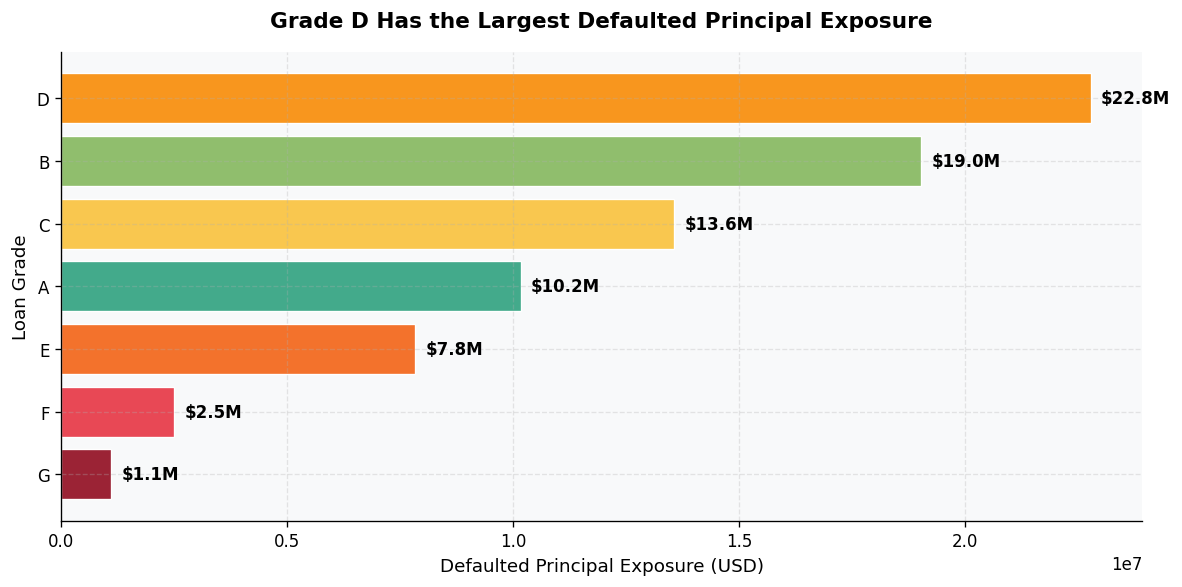

Insight: Grade D has the largest defaulted principal exposure in the portfolio.
Insight: Absolute exposure depends on both default risk and the number and size of loans within each grade.
Insight: Reducing high-risk lending exposure in the grades with the largest defaulted principal could materially reduce portfolio risk.


In [27]:
# Chart 7 - Defaulted Principal Exposure by Loan Grade
# Business Question:
# Which loan grade has the largest principal exposure from defaulted loans?

# Calculate total principal associated with defaulted loans
exposure_data = (
    df[df['loan_status'] == 1]
      .groupby('loan_grade')['loan_amnt']
      .sum()
      .reset_index()
)

exposure_data.columns = ['loan_grade', 'total_exposure']
exposure_data = exposure_data.sort_values('total_exposure', ascending=True)

# Find the grade with the highest financial exposure
highest_grade = exposure_data.loc[
    exposure_data['total_exposure'].idxmax(),
    'loan_grade'
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Create horizontal bars
bars = ax.barh(
    exposure_data['loan_grade'],
    exposure_data['total_exposure'],
    color=[GRADE_COLORS[g] for g in exposure_data['loan_grade']],
    edgecolor='white',
    linewidth=0.8
)

# Add exposure labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (exposure_data['total_exposure'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'${width/1e6:.1f}M',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Chart title
ax.set_title(
    f'Grade {highest_grade} Has the Largest Defaulted Principal Exposure',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Defaulted Principal Exposure (USD)',fontsize=11)
ax.set_ylabel('Loan Grade', fontsize=11)

plt.tight_layout()
plt.savefig('chart7_financial_exposure_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    f'Insight: Grade {highest_grade} has the largest '
    'defaulted principal exposure in the portfolio.'
)

print(
    'Insight: Absolute exposure depends on both default risk '
    'and the number and size of loans within each grade.'
)

print(
    'Insight: Reducing high-risk lending exposure in the grades '
    'with the largest defaulted principal could materially reduce '
    'portfolio risk.'
)

## Chart 8 — Estimated Interest Proxy vs Defaulted Principal Exposure by Grade

**Business question:** Which loan grades generate more estimated interest revenue than defaulted principal exposure?

**Why this chart:** Default rates alone do not show the financial trade-off between interest income and default exposure. This analysis compares estimated interest revenue from repaid loans with principal exposure from defaulted loans.

**What we expect:** Lower-risk grades may show a more favorable relationship between estimated interest and defaulted principal exposure, while higher-risk grades may show greater defaulted principal exposure.

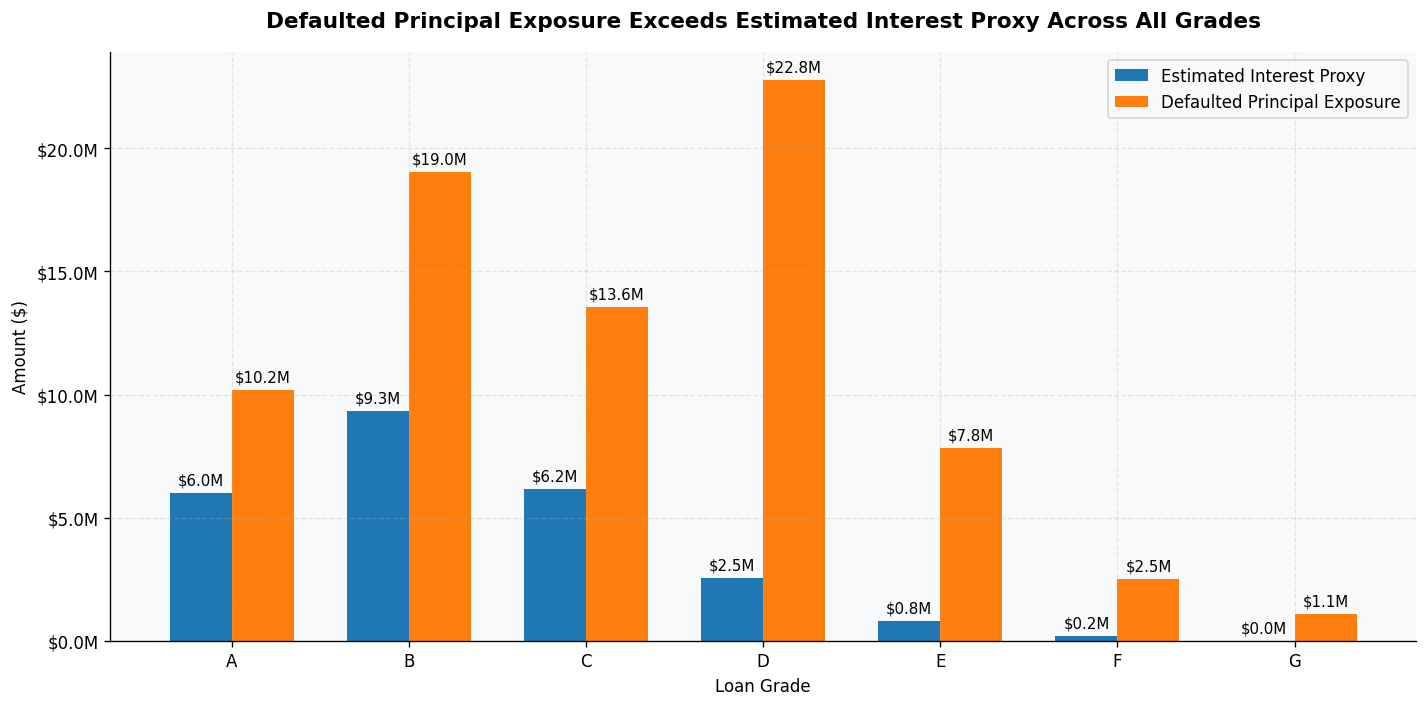

Insight: Grades A, B, C, D, E, F, G have defaulted principal exposure exceeding the estimated interest proxy.
Insight: This comparison is a simplified financial proxy using one-period interest revenue and defaulted principal exposure.
Insight: The results should be interpreted as portfolio risk economics, not as a complete accounting profit calculation.


In [28]:
## Chart 8 — Estimated Interest Proxy vs Defaulted Principal Exposure by Grade
## Business question: How does estimated one-period interest from repaid loans compare with defaulted principal exposure across loan grades?

import matplotlib.ticker as mtick
interest_proxy = (
    df[df['loan_status'] == 0]
      .groupby('loan_grade')
      .apply(
          lambda x: (
              x['loan_amnt'] * x['loan_int_rate'] / 100
          ).sum()
      )
      .reset_index()
)

interest_proxy.columns = ['loan_grade', 'interest_proxy']

defaulted_principal = (
    df[df['loan_status'] == 1]
      .groupby('loan_grade')['loan_amnt']
      .sum()
      .reset_index()
)

defaulted_principal.columns = ['loan_grade', 'defaulted_principal']

grade_financial_proxy = interest_proxy.merge(
    defaulted_principal,
    on='loan_grade'
)

grade_financial_proxy = grade_financial_proxy.sort_values('loan_grade')

# Calculate simplified difference
grade_financial_proxy['exposure_interest_difference'] = (
    grade_financial_proxy['interest_proxy']
    - grade_financial_proxy['defaulted_principal']
)

grades = grade_financial_proxy['loan_grade'].values

x = np.arange(len(grades))
width = 0.35

# Identify grades where defaulted principal exposure exceeds interest proxy
loss_making = grade_financial_proxy.loc[
    grade_financial_proxy['defaulted_principal']
    > grade_financial_proxy['interest_proxy'],
    'loan_grade'
].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width / 2,
    grade_financial_proxy['interest_proxy'],
    width,
    label='Estimated Interest Proxy'
)

bars2 = ax.bar(
    x + width / 2,
    grade_financial_proxy['defaulted_principal'],
    width,
    label='Defaulted Principal Exposure'
)

ax.set_xlabel('Loan Grade')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(grades)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'${x / 1_000_000:.1f}M')
)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (grade_financial_proxy['defaulted_principal'].max() * 0.01),
        f'${height / 1_000_000:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (grade_financial_proxy['defaulted_principal'].max() * 0.01),
        f'${height / 1_000_000:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Dynamic title
if len(loss_making) == len(grades):
    title = (
        'Defaulted Principal Exposure Exceeds Estimated Interest Proxy '
        'Across All Grades'
    )
elif loss_making:
    title = (
        f"Grades {', '.join(loss_making)} Have Higher Defaulted Principal "
        f"Exposure Than Interest Proxy"
    )
else:
    title = (
        'Estimated Interest Proxy Exceeds Defaulted Principal Exposure '
        'Across All Grades'
    )

ax.set_title(
    title,
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("chart8_revenue_vs_loss_by_grade.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Print key insights
print(
    f'Insight: Grades {", ".join(loss_making) if loss_making else "none"} '
    'have defaulted principal exposure exceeding the estimated interest proxy.'
)

print(
    'Insight: This comparison is a simplified financial proxy using '
    'one-period interest revenue and defaulted principal exposure.'
)

print(
    'Insight: The results should be interpreted as portfolio risk economics, '
    'not as a complete accounting profit calculation.'
)

## Chart 9 — Age Group vs Default Rate

**Business question:** Which age segment carries the highest default risk at FinTrust?

**Why this chart:** Young borrowers have shorter employment history and less
financial experience. This chart validates whether age is a meaningful risk factor.

**What we expect:** Default rates may differ across age groups, with younger borrowers potentially showing higher risk. The analysis will determine whether age is a meaningful portfolio-level risk indicator.

               age_group  borrower_count  default_rate
2    Mid Career\n(36-50)            3172         20.55
1  Early Career\n(25-35)           16734         20.98
0      Young\n(Under 25)           12222         23.34
3          Senior\n(>50)             288         25.35


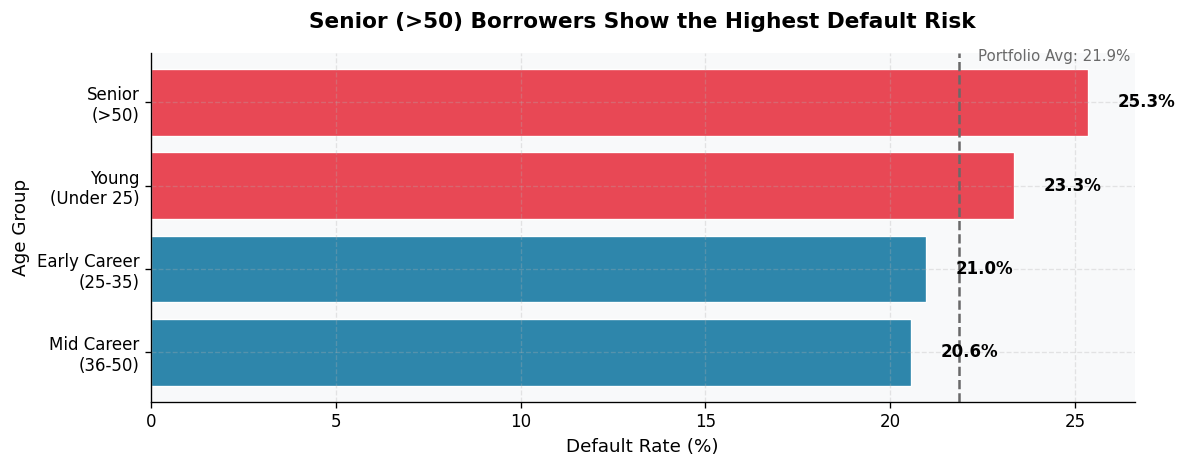

Insight: Senior (>50) borrowers have the highest observed default rate at 25.35%.
Insight: Default rates vary across age groups, indicating that borrower age may provide additional context for credit-risk assessment.
Insight: Age should be considered alongside stronger financial risk indicators such as loan grade, debt burden, income, and prior default history.


In [29]:
# Chart 9 - Age Group vs Default Rate
# Business Question: Which age group has the highest default risk?

# Create age groups
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[-1, 24, 35, 50, 150],
    labels=['Young\n(Under 25)', 'Early Career\n(25-35)', 'Mid Career\n(36-50)', 'Senior\n(>50)']
)
# Calculate default rate for each age group
age_data = (
    df.groupby('age_group', observed=True)['loan_status']
      .mean()
      .reset_index()
)

age_data['default_rate'] = age_data['loan_status'] * 100
age_data = age_data.sort_values('default_rate', ascending=True)

age_data['borrower_count'] = (
    df.groupby('age_group', observed=True)
      .size()
      .reindex(age_data['age_group'])
      .values
)

print(age_data[['age_group', 'borrower_count', 'default_rate']].round(2))

# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100

# Set bar colours based on portfolio average
bar_colors = [
    COLORS['danger'] if rate > portfolio_avg else COLORS['primary']
    for rate in age_data['default_rate']
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))

# Create horizontal bars
bars = ax.barh(
    age_data['age_group'],
    age_data['default_rate'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Portfolio average reference line
ax.axvline(
    portfolio_avg,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Label the reference line
ax.text(
    portfolio_avg + 0.5,
    len(age_data) - 0.5,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9,
    color='dimgray'
)

# Chart title — dynamically generated from the actual highest-risk group
highest_group = age_data.iloc[-1]['age_group'].replace('\n', ' ')
ax.set_title(
    f'{highest_group} Borrowers Show the Highest Default Risk',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Default Rate (%)', fontsize=11)
ax.set_ylabel('Age Group', fontsize=11)

plt.tight_layout()
plt.savefig('chart9_age_group_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    f'Insight: {highest_group} borrowers have the highest observed default rate '
    f'at {age_data.iloc[-1]["default_rate"]:.2f}%.'
)

print(
    'Insight: Default rates vary across age groups, indicating that borrower age '
    'may provide additional context for credit-risk assessment.'
)

print(
    'Insight: Age should be considered alongside stronger financial risk indicators '
    'such as loan grade, debt burden, income, and prior default history.'
)

## Chart 10 — Composite Risk Flag: Early Warning System Validation

**Business question:** Does FinTrust's composite risk flag successfully separate
high-risk borrowers from normal borrowers?

**Why this chart:** This is the final and most important chart. It validates
the Early Warning System we built in Q10. If the flag works, high-risk borrowers
should default at significantly higher rates than normal borrowers.

**What we expect:** Borrowers flagged as High Risk should have a substantially higher observed default rate than Normal borrowers.

**Business meaning:** A strong separation would support using the flag as a candidate early-warning rule for manual review. Further out-of-sample validation would be required before operational deployment.


Risk Flag Performance:
   risk_flag  count  default_rate
0  High Risk   7228         44.45
1     Normal  25188         15.39


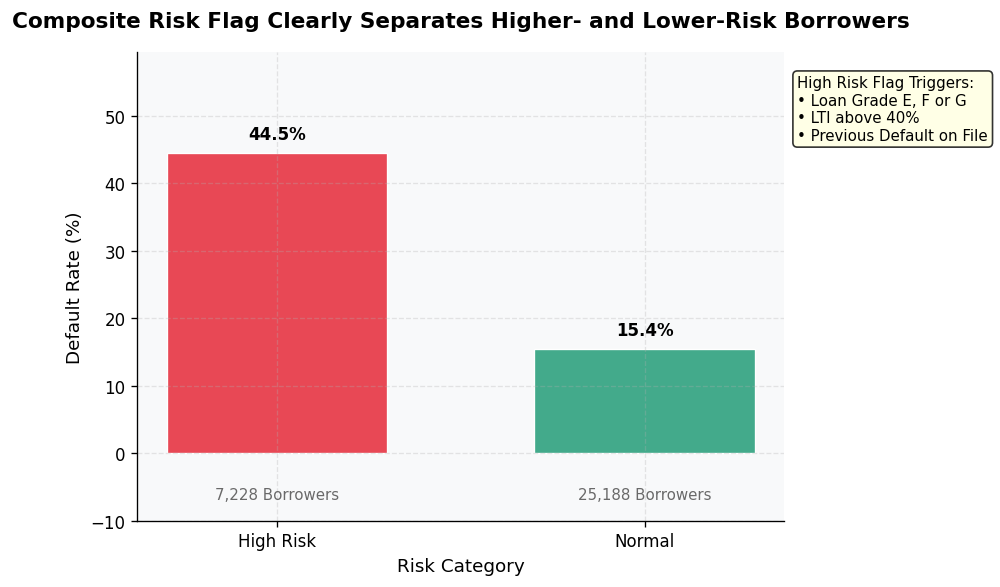

Insight: High Risk borrowers default at 44.45% compared with 15.39% for Normal borrowers.
Insight: The High Risk group has approximately 2.89x the observed default rate of the Normal group.
Insight: The composite flag provides a strong candidate for an early-warning review rule, but requires out-of-sample validation before production deployment.


In [30]:
# Chart 10 - Composite Risk Flag Validation
# Business Question:
# Does the early warning system correctly identify high-risk borrowers?

# ---------------------------------------------------------
# 1. Create the composite risk flag
# ---------------------------------------------------------

df['risk_flag'] = np.where(
    (df['loan_grade'].isin(['E', 'F', 'G'])) |
    (df['loan_percent_income'] > 0.40) |
    (df['cb_person_default_on_file'] == 'Y'),
    'High Risk',
    'Normal'
)

# ---------------------------------------------------------
# 2. Calculate default performance by risk group
# ---------------------------------------------------------

flag_data = (
    df.groupby('risk_flag')['loan_status']
      .agg(['mean', 'count'])
      .reset_index()
)

flag_data['default_rate'] = flag_data['mean'] * 100

flag_data = flag_data.sort_values(
    'default_rate',
    ascending=False
)

# Display risk-group summary
print("\nRisk Flag Performance:")
print(
    flag_data[
        ['risk_flag', 'count', 'default_rate']
    ].round(2)
)

# ---------------------------------------------------------
# 3. Set colours for each risk group
# ---------------------------------------------------------

bar_colors = [
    COLORS['danger'] if risk == 'High Risk' else COLORS['safe']
    for risk in flag_data['risk_flag']
]

# ---------------------------------------------------------
# 4. Create chart
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    flag_data['risk_flag'],
    flag_data['default_rate'],
    color=bar_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default-rate labels
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add borrower counts
for bar, count in zip(bars, flag_data['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -5,
        f'{count:,} Borrowers',
        ha='center',
        va='top',
        fontsize=9,
        color='dimgray'
    )

# Explain risk triggers
ax.text(
    1.02,
    0.95,
    "High Risk Flag Triggers:\n"
    "• Loan Grade E, F or G\n"
    "• LTI above 40%\n"
    "• Previous Default on File",
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='lightyellow',
        alpha=0.8
    )
)

# Chart title
ax.set_title(
    'Composite Risk Flag Clearly Separates Higher- and Lower-Risk Borrowers',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Risk Category', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)

ax.set_ylim(
    -10,
    max(flag_data['default_rate']) + 15
)

plt.tight_layout()

plt.savefig(
    'chart10_risk_flag_validation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ---------------------------------------------------------
# 5. Business insights
# ---------------------------------------------------------

high_risk_rate = flag_data.loc[
    flag_data['risk_flag'] == 'High Risk',
    'default_rate'
].iloc[0]

normal_rate = flag_data.loc[
    flag_data['risk_flag'] == 'Normal',
    'default_rate'
].iloc[0]

risk_ratio = high_risk_rate / normal_rate

print(
    f'Insight: High Risk borrowers default at '
    f'{high_risk_rate:.2f}% compared with '
    f'{normal_rate:.2f}% for Normal borrowers.'
)

print(
    f'Insight: The High Risk group has approximately '
    f'{risk_ratio:.2f}x the observed default rate '
    f'of the Normal group.'
)

print(
    'Insight: The composite flag provides a strong '
    'candidate for an early-warning review rule, but '
    'requires out-of-sample validation before production deployment.'
)

## Final Statistical Validation

The key risk indicators identified during exploratory analysis are statistically validated below.

The objective is to determine whether the observed differences in default rates are likely to represent genuine risk relationships rather than random variation.

In [31]:
from scipy.stats import chi2_contingency

grade_table = pd.crosstab(df['loan_grade'], df['loan_status'])
chi2, p_value, dof, expected = chi2_contingency(grade_table)

print(f"Loan grade vs default")
print(f"Chi-square statistic: {chi2:.2f}, dof: {dof}")
print(f"P-value: {p_value:.10f}")

Loan grade vs default
Chi-square statistic: 5588.33, dof: 6
P-value: 0.0000000000


### Interpretation

The chi-square test confirms that default status is significantly associated with loan grade (χ² = 5588.33, df = 6, p < 0.001). This provides formal statistical support for the pattern observed throughout the exploratory analysis: default rates differ meaningfully across FinTrust's seven loan grades, and this is very unlikely to be due to chance.

## Statistical Validation — Composite Risk Flag

The composite risk flag combines three observed risk indicators:

- Loan grade E, F, or G
- Loan-to-income ratio above 40%
- Previous default on file

A two-proportion z-test is used to determine whether the difference in default rates between High Risk and Normal borrowers is statistically significant.

In [32]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

# ---------------------------------------------------------
# 1. Summarize default performance by risk flag
# ---------------------------------------------------------

risk_summary = (
    df.groupby('risk_flag')['loan_status']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'total_loans',
          'sum': 'defaults',
          'mean': 'default_rate'
      })
)

# Convert default rate to percentage
risk_summary['default_rate'] *= 100

print("Composite Risk Flag Performance")
print("-" * 50)
print(risk_summary.round(2))


# ---------------------------------------------------------
# 2. Extract High Risk and Normal group statistics
# ---------------------------------------------------------

high_risk_defaults = int(
    risk_summary.loc['High Risk', 'defaults']
)

high_risk_total = int(
    risk_summary.loc['High Risk', 'total_loans']
)

normal_defaults = int(
    risk_summary.loc['Normal', 'defaults']
)

normal_total = int(
    risk_summary.loc['Normal', 'total_loans']
)


# ---------------------------------------------------------
# 3. Two-proportion z-test
# ---------------------------------------------------------

default_counts = [
    high_risk_defaults,
    normal_defaults
]

sample_sizes = [
    high_risk_total,
    normal_total
]

z_stat, p_value = proportions_ztest(
    count=default_counts,
    nobs=sample_sizes,
    alternative='two-sided'
)


# ---------------------------------------------------------
# 4. Calculate risk difference
# ---------------------------------------------------------

high_risk_rate = high_risk_defaults / high_risk_total
normal_rate = normal_defaults / normal_total

risk_difference = (
    high_risk_rate - normal_rate
) * 100


# ---------------------------------------------------------
# 5. Calculate confidence interval for risk difference
# ---------------------------------------------------------

ci_low, ci_high = confint_proportions_2indep(
    count1=high_risk_defaults,
    nobs1=high_risk_total,
    count2=normal_defaults,
    nobs2=normal_total,
    compare='diff',
    method='wald'
)

ci_low *= 100
ci_high *= 100


# ---------------------------------------------------------
# 6. Calculate risk ratio
# ---------------------------------------------------------

risk_ratio = high_risk_rate / normal_rate


# ---------------------------------------------------------
# 7. Display statistical results
# ---------------------------------------------------------

print("\nStatistical Validation")
print("-" * 50)

print(f"High Risk default rate: {high_risk_rate * 100:.2f}%")
print(f"Normal default rate: {normal_rate * 100:.2f}%")

print(f"\nRisk difference: {risk_difference:.2f} percentage points")
print(
    f"95% CI for risk difference: "
    f"{ci_low:.2f} to {ci_high:.2f} percentage points"
)

print(f"\nRisk ratio: {risk_ratio:.2f}x")
print(f"Z-statistic: {z_stat:.2f}")
print(f"P-value: {p_value:.10f}")


# ---------------------------------------------------------
# 8. Statistical conclusion
# ---------------------------------------------------------

if p_value < 0.05:
    print(
        "\nConclusion: The difference in default rates between "
        "High Risk and Normal borrowers is statistically significant "
        "at the 5% significance level."
    )
else:
    print(
        "\nConclusion: The difference in default rates between "
        "High Risk and Normal borrowers is not statistically "
        "significant at the 5% significance level."
    )

Composite Risk Flag Performance
--------------------------------------------------
           total_loans  defaults  default_rate
risk_flag                                     
High Risk         7228      3213         44.45
Normal           25188      3876         15.39

Statistical Validation
--------------------------------------------------
High Risk default rate: 44.45%
Normal default rate: 15.39%

Risk difference: 29.06 percentage points
95% CI for risk difference: 27.83 to 30.29 percentage points

Risk ratio: 2.89x
Z-statistic: 52.69
P-value: 0.0000000000

Conclusion: The difference in default rates between High Risk and Normal borrowers is statistically significant at the 5% significance level.


### Interpretation

The two-proportion z-test evaluates whether the observed difference in default rates between High Risk and Normal borrowers is statistically significant.

A statistically significant result indicates that the observed separation between the two groups is unlikely to be explained by random sampling variation alone.

The risk difference quantifies the absolute increase in default probability, while the risk ratio shows how many times higher the observed default rate is among High Risk borrowers.

The 95% confidence interval provides an uncertainty range around the estimated risk difference.

These results support the composite flag as a **candidate early-warning screening rule**. However, statistical significance alone does not establish predictive performance or justify production deployment. Further out-of-sample validation would be required before using the rule operationally.

## Consolidated Risk Driver Summary

The analysis identifies several borrower and loan characteristics associated with elevated default risk. The table below consolidates the strongest observed risk signals identified throughout the analysis.

This summary is intended to support business decision-making and prioritization of risk controls rather than to represent a predictive model.

In [33]:
# Consolidated Risk Driver Summary

risk_driver_summary = pd.DataFrame({
    'Risk Driver': [
        'Previous Default History',
        'Loan Grade',
        'Loan-to-Income Ratio',
        'Income Level',
        'Loan Intent',
        'Composite Risk Flag'
    ],
    'Observed Risk Signal': [
        'Previous defaulters show substantially higher default risk',
        'Lower loan grades are associated with higher default rates',
        'Higher LTI is associated with increased default risk',
        'Lower-income borrowers show elevated default risk',
        'Default rates vary meaningfully across loan purposes',
        'High Risk borrowers have substantially higher observed default rates'
    ],
    'Business Relevance': [
        'Strong indicator of borrower repayment risk',
        'Useful for credit pricing and approval decisions',
        'Indicates repayment capacity pressure',
        'Helps identify financially vulnerable borrowers',
        'Supports intent-specific risk policies',
        'Useful as an early-warning screening rule'
    ]
})

display(risk_driver_summary)

,Risk Driver,Observed Risk Signal,Business Relevance
0,Previous Default History,Previous defaulters show substantially higher ...,Strong indicator of borrower repayment risk
1,Loan Grade,Lower loan grades are associated with higher d...,Useful for credit pricing and approval decisions
2,Loan-to-Income Ratio,Higher LTI is associated with increased defaul...,Indicates repayment capacity pressure
3,Income Level,Lower-income borrowers show elevated default risk,Helps identify financially vulnerable borrowers
4,Loan Intent,Default rates vary meaningfully across loan pu...,Supports intent-specific risk policies
5,Composite Risk Flag,High Risk borrowers have substantially higher ...,Useful as an early-warning screening rule


## Financial Impact of Loan Defaults

Understanding default frequency alone is not sufficient for credit-risk decision-making. FinTrust also needs to understand the financial exposure associated with defaulted loans.

The following analysis quantifies the principal exposure from defaulted loans and compares it with interest revenue generated from loans that were repaid.

In [34]:
# Financial Impact Analysis

# ---------------------------------------------------------
# 1. Calculate principal exposure from defaulted loans
# ---------------------------------------------------------

defaulted_loans = df[df['loan_status'] == 1]

repaid_loans = df[df['loan_status'] == 0]

defaulted_principal = defaulted_loans['loan_amnt'].sum()

repaid_principal = repaid_loans['loan_amnt'].sum()


# ---------------------------------------------------------
# 2. Estimate interest revenue from repaid loans
# ---------------------------------------------------------

repaid_interest_revenue = (
    repaid_loans['loan_amnt'] *
    repaid_loans['loan_int_rate'] / 100
).sum()


# ---------------------------------------------------------
# 3. Calculate net portfolio position
# ---------------------------------------------------------

net_portfolio_position = (
    repaid_interest_revenue -
    defaulted_principal
)


# ---------------------------------------------------------
# 4. Display financial impact with business-friendly formatting
# ---------------------------------------------------------

financial_impact = pd.DataFrame({
    'Metric': [
        'Total Loans',
        'Defaulted Loans',
        'Repaid Loans',
        'Principal Exposure from Defaults',
        'Estimated Interest Revenue from Repaid Loans',
        'Net Portfolio Position'
    ],
    'Value': [
        f"{len(df):,}",
        f"{len(defaulted_loans):,}",
        f"{len(repaid_loans):,}",
        f"${defaulted_principal:,.0f}",
        f"${repaid_interest_revenue:,.0f}",
        f"${net_portfolio_position:,.0f}"
    ]
})

financial_impact

,Metric,Value
0,Total Loans,"32,416"
1,Defaulted Loans,"7,089"
2,Repaid Loans,"25,327"
3,Principal Exposure from Defaults,"$76,968,675"
4,Estimated Interest Revenue from Repaid Loans,"$25,003,819"
5,Net Portfolio Position,"$-51,964,856"


In [35]:
# Format financial impact for business interpretation

print("FINTRUST FINANCIAL IMPACT")
print("=" * 50)

print(f"Total loans: {len(df):,}")
print(f"Defaulted loans: {len(defaulted_loans):,}")
print(f"Repaid loans: {len(repaid_loans):,}")

print(
    f"\nPrincipal exposure from defaults: "
    f"${defaulted_principal:,.0f}"
)

print(
    f"Estimated interest revenue from repaid loans: "
    f"${repaid_interest_revenue:,.0f}"
)

print(
    f"Net portfolio position: "
    f"${net_portfolio_position:,.0f}"
)

FINTRUST FINANCIAL IMPACT
Total loans: 32,416
Defaulted loans: 7,089
Repaid loans: 25,327

Principal exposure from defaults: $76,968,675
Estimated interest revenue from repaid loans: $25,003,819
Net portfolio position: $-51,964,856


### Financial Interpretation

The financial impact analysis demonstrates that the cost of loan defaults extends beyond the default rate itself. Defaulted loans represent direct principal exposure, while interest revenue from repaid loans provides only a partial offset.

The resulting net portfolio position highlights the importance of identifying high-risk borrowers before loan losses occur.

These estimates are analytical rather than accounting measures because they use the available loan amount and stated interest rate fields and do not model repayment timing, amortization, fees, recoveries, collateral, or collection costs.

## Final Business Recommendations

Based on the portfolio analysis, statistical validation, risk-driver analysis, and financial impact assessment, FinTrust Lending Co. should take the following actions:

1. **Strengthen underwriting for borrowers with prior default history**
   - Prior default history is a significant indicator of elevated future default risk.
   - Introduce enhanced credit-history review and affordability verification for applicants with previous defaults.

2. **Apply additional scrutiny to high-debt-burden borrowers**
   - Borrowers with high loan-to-income ratios represent a higher-risk segment.
   - Consider stricter affordability thresholds, lower loan exposure, or additional verification for borrowers with elevated LTI.

3. **Use the composite risk flag as an early-warning indicator**
   - The analytically evaluated risk flag can help identify borrowers exhibiting multiple risk characteristics simultaneously.
   - High-risk borrowers should receive enhanced monitoring and review rather than relying solely on a single risk factor.

4. **Adopt risk-based lending policies**
   - Different borrower risk segments should receive appropriately differentiated underwriting, loan exposure, and monitoring policies.
   - This can help FinTrust balance portfolio growth with credit-risk control.

5. **Prioritize financial exposure alongside default rates**
   - Risk management should consider both the probability of default and the financial value exposed to potential losses.
   - Monitoring high-value loans within elevated-risk segments can help reduce the potential financial impact of defaults.

6. **Continuously monitor portfolio risk**
   - Default rates, risk-driver performance, financial exposure, and the composite risk flag should be monitored periodically.
   - Changes in portfolio composition or borrower behavior should trigger a review of lending policies and risk thresholds.

## Limitations and Responsible Interpretation

This analysis is based on historical observational credit-risk data. The identified relationships describe associations between borrower characteristics and loan defaults and should not be interpreted as proof of causation.

The composite risk flag is an analytical early-warning indicator created for this project. Although statistical testing provides evidence that the flagged group has a different observed default rate, the flag should not be treated as a production-ready credit-scoring model.

The dataset may not contain all factors that influence credit outcomes, such as detailed repayment behavior, borrower cash-flow information, collateral, macroeconomic conditions, or changes in lending policies over time.

Before deployment in a real lending environment, the risk framework would require validation on unseen data, threshold optimization, fairness and bias assessment, model-performance monitoring, and periodic recalibration.

Therefore, the findings should be used to support credit-risk assessment and human decision-making rather than automatically approve or reject borrowers.

## Executive Conclusion

FinTrust Lending Co. is facing a significant credit-risk challenge, with a portfolio default rate of approximately **21.87%** and substantial financial exposure associated with defaulted loans.

The analysis identified several important risk drivers, including **prior default history, debt burden, income-related characteristics, and borrower risk segments**. The composite risk flag further demonstrates how multiple risk characteristics can be combined into an early-warning indicator for identifying borrowers with elevated observed default risk.

From a business perspective, FinTrust should move from a primarily reactive approach to a more proactive risk-management strategy. Stronger underwriting for high-risk applicants, enhanced monitoring of elevated-risk borrowers, risk-based lending policies, and continuous monitoring of financial exposure can help reduce potential losses.

The analysis provides a strong foundation for an **Early Warning System**, but the composite risk flag should not be considered a production-ready credit-scoring model. Before deployment, it would require validation on unseen data, fairness assessment, threshold optimization, and ongoing performance monitoring.

Overall, the key objective for FinTrust should be to **identify elevated-risk borrowers earlier, prioritize the highest financial exposures, and use data-driven risk controls to reduce future credit losses while maintaining responsible lending practices.**